# 4) Utilización de Variables Categóricas - Gender Classifier

**Objetivo:** Transformar las variables categóricas del dataset limpio para que puedan ser utilizadas en un modelo de clasificación, justificando cada proceso de transformación.

**Estrategia:**
1. Construir un modelo **baseline** usando solo variables numéricas (sin categóricas).
2. Identificar y transformar las variables categóricas con técnicas apropiadas.
3. Reconstruir el modelo incluyendo las variables categóricas transformadas.
4. Comparar el rendimiento de ambos modelos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", None)

SEED = 42
np.random.seed(SEED)

In [2]:
import os

_candidates = [
    "data/gender-classifier-clean.csv",
    "../data/gender-classifier-clean.csv",
    "/app/data/gender-classifier-clean.csv",
]
DATA_PATH = next(p for p in _candidates if os.path.exists(p))

df = pd.read_csv(DATA_PATH)
print(f"Archivo cargado desde: {DATA_PATH}")
print(f"Dimensiones: {df.shape}")
df.head(3)

Archivo cargado desde: ../data/gender-classifier-clean.csv
Dimensiones: (18836, 26)


,gender,description,text,name,desc_length,desc_word_count,text_length,text_word_count,name_length,fav_number,tweet_count,retweet_count,fav_number_log,tweet_count_log,retweet_count_log,link_color_r,link_color_g,link_color_b,sidebar_color_r,sidebar_color_g,sidebar_color_b,tweet_location,user_timezone,account_age_days,created_year,created_month
0,male,i sing my own rhythm.,Robbie E Responds To Critics After Win Against...,sheezy0,21,5,109,14,7,0,110964,0,0.000000,11.616970,0.000000,0.031373,0.760784,0.760784,1.000000,1.000000,1.000000,main; @Kan1shk3,Chennai,689,2013,12
1,male,I'm the author of novels filled with family dr...,ÛÏIt felt like they were my friends and I was...,DavdBurnett,62,11,139,19,11,68,7471,0,4.234107,8.918918,0.000000,0.000000,0.517647,0.705882,0.752941,0.870588,0.929412,unknown,Eastern Time (US & Canada),1119,2012,10
2,male,louis whining and squealing and all,i absolutely adore when louis starts the songs...,lwtprettylaugh,35,6,80,16,14,7696,5617,1,8.948586,8.633731,0.693147,0.670588,0.721569,0.760784,0.752941,0.870588,0.929412,clcncl,Belgrade,331,2014,11


## 1. Identificación de Variables Categóricas

Del dataset limpio, clasificamos cada variable según su naturaleza:

In [3]:
# Clasificación de variables por tipo
var_objetivo = ["gender"]

var_numericas = [
    "desc_length", "desc_word_count", "text_length", "text_word_count", "name_length",
    "fav_number", "tweet_count", "retweet_count",
    "fav_number_log", "tweet_count_log", "retweet_count_log",
    "link_color_r", "link_color_g", "link_color_b",
    "sidebar_color_r", "sidebar_color_g", "sidebar_color_b",
    "account_age_days", "created_year", "created_month",
]

var_categoricas = ["tweet_location", "user_timezone"]
var_texto = ["description", "text", "name"]

print(f"Variable objetivo:      {len(var_objetivo)}  → {var_objetivo}")
print(f"Variables numéricas:    {len(var_numericas)}")
print(f"Variables categóricas:  {len(var_categoricas)} → {var_categoricas}")
print(f"Variables de texto:     {len(var_texto)}  → {var_texto}")

print("\n=== Detalle de variables categóricas ===")
for col in var_categoricas:
    print(f"\n{col}:")
    print(f"  Valores únicos: {df[col].nunique()}")
    print(f"  Top 5: {df[col].value_counts().head().to_dict()}")

Variable objetivo:      1  → ['gender']
Variables numéricas:    20
Variables categóricas:  2 → ['tweet_location', 'user_timezone']
Variables de texto:     3  → ['description', 'text', 'name']

=== Detalle de variables categóricas ===

tweet_location:
  Valores únicos: 7537
  Top 5: {'unknown': 6843, 'London': 147, 'United States': 140, 'USA': 93, 'UK': 91}

user_timezone:
  Valores únicos: 154
  Top 5: {'unknown': 7183, 'Eastern Time (US & Canada)': 2398, 'Pacific Time (US & Canada)': 1992, 'Central Time (US & Canada)': 1451, 'London': 1240}


## 2. Modelo Baseline (Solo Variables Numéricas)

Primero construimos un modelo usando **únicamente las variables numéricas**, sin incluir las variables categóricas ni de texto. Esto establece una línea base de rendimiento contra la cual compararemos el modelo mejorado.

In [4]:
# Codificar la variable objetivo
le = LabelEncoder()
df["gender_encoded"] = le.fit_transform(df["gender"])
print(f"Clases: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Preparar datos para el baseline
X_num = df[var_numericas].copy()
y = df["gender_encoded"].copy()

print(f"\nFeatures numéricas: {X_num.shape[1]}")
print(f"Registros: {len(y)}")
print(f"\nDistribución de clases:")
print(y.value_counts().sort_index().rename(dict(zip(le.transform(le.classes_), le.classes_))))

Clases: {'brand': np.int64(0), 'female': np.int64(1), 'male': np.int64(2)}

Features numéricas: 20
Registros: 18836

Distribución de clases:
gender_encoded
brand     5942
female    6700
male      6194
Name: count, dtype: int64


In [5]:
# Split train/test
X_train_num, X_test_num, y_train, y_test = train_test_split(
    X_num, y, test_size=0.2, random_state=SEED, stratify=y
)

# Escalar features numéricas
scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_train_num)
X_test_num_scaled = scaler.transform(X_test_num)

# Entrenar modelo baseline
model_baseline = LogisticRegression(max_iter=1000, random_state=SEED)
model_baseline.fit(X_train_num_scaled, y_train)

# Evaluar
y_pred_baseline = model_baseline.predict(X_test_num_scaled)
acc_baseline = accuracy_score(y_test, y_pred_baseline)

print(f"=== MODELO BASELINE (solo numéricas) ===")
print(f"Accuracy: {acc_baseline:.4f}\n")
print(classification_report(y_test, y_pred_baseline, target_names=le.classes_))

=== MODELO BASELINE (solo numéricas) ===
Accuracy: 0.5671

              precision    recall  f1-score   support

       brand       0.65      0.66      0.65      1189
      female       0.55      0.59      0.57      1340
        male       0.50      0.45      0.48      1239

    accuracy                           0.57      3768
   macro avg       0.57      0.57      0.57      3768
weighted avg       0.57      0.57      0.57      3768



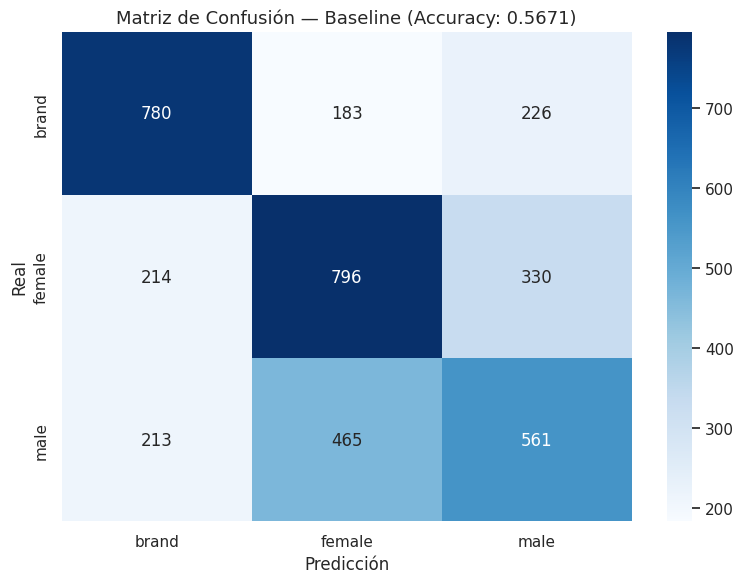

In [6]:
# Matriz de confusión del baseline
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_baseline)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_title(f"Matriz de Confusión — Baseline (Accuracy: {acc_baseline:.4f})", fontsize=13)
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

## 3. Transformación de Variables Categóricas

Ahora aplicamos transformaciones a las variables categóricas para convertirlas en representaciones numéricas que el modelo pueda procesar.

### Estrategia de transformación por variable:

| Variable | Cardinalidad | Técnica | Justificación |
|---|---|---|---|
| `user_timezone` | ~153 valores | **One-Hot Encoding** (top 15 + "other") | Cardinalidad moderada. Al agrupar categorías poco frecuentes en "other", evitamos la explosión dimensional manteniendo las zonas más representativas. Es variable **nominal** (sin orden), por lo que one-hot es apropiado. |
| `tweet_location` | ~7,500 valores | **Frequency Encoding** | Cardinalidad muy alta, one-hot generaría miles de columnas. El frequency encoding mapea cada categoría a su frecuencia relativa, capturando que ubicaciones populares comparten patrones similares. |
| `description` | Texto libre | **TF-IDF** | Texto no estructurado. TF-IDF convierte texto a vectores numéricos ponderando la importancia de cada término. Captura patrones lingüísticos (pronombres, profesiones, intereses) indicativos del género. |
| `text` | Texto libre | **TF-IDF** | Mismo razonamiento. El contenido del tweet refleja estilo y vocabulario que puede diferir entre géneros. |
| `name` | Texto (nombres) | **TF-IDF** (nivel carácter) | Los nombres propios son fuertes indicadores de género. Se usa TF-IDF a nivel de **n-gramas de caracteres** para capturar patrones como sufijos ("a"/"o" en español, "ina"/"son" en inglés). |

### 3.1 One-Hot Encoding: `user_timezone`

**Justificación:** `user_timezone` tiene ~153 valores únicos, una cardinalidad moderada. Se seleccionan las top 15 zonas horarias más frecuentes y se agrupan las demás como `"other"`. Luego se aplica one-hot encoding, que crea una columna binaria por cada categoría. Esta técnica es adecuada porque:
- La variable es **nominal** (no tiene un orden intrínseco entre zonas horarias).
- Al limitar a las top 15 + other, se controla la dimensionalidad (16 columnas en vez de 153).
- Las zonas horarias reflejan ubicación geográfica, que puede correlacionarse con patrones culturales de género en redes sociales.

In [7]:
# One-Hot Encoding para user_timezone
TOP_N_TZ = 15

top_tz = df["user_timezone"].value_counts().head(TOP_N_TZ).index.tolist()
print(f"Top {TOP_N_TZ} zonas horarias (cubren {df['user_timezone'].isin(top_tz).mean()*100:.1f}% de los datos):")
for i, tz in enumerate(top_tz, 1):
    count = (df["user_timezone"] == tz).sum()
    print(f"  {i:2d}. {tz:40s} ({count:,} registros)")

# Agrupar categorías poco frecuentes en "other"
df["tz_grouped"] = df["user_timezone"].where(df["user_timezone"].isin(top_tz), other="other")

# Aplicar one-hot encoding
tz_dummies = pd.get_dummies(df["tz_grouped"], prefix="tz", dtype=int)
print(f"\nColumnas generadas por One-Hot: {tz_dummies.shape[1]}")
print(tz_dummies.head())

Top 15 zonas horarias (cubren 90.4% de los datos):
   1. unknown                                  (7,183 registros)
   2. Eastern Time (US & Canada)               (2,398 registros)
   3. Pacific Time (US & Canada)               (1,992 registros)
   4. Central Time (US & Canada)               (1,451 registros)
   5. London                                   (1,240 registros)
   6. Atlantic Time (Canada)                   (566 registros)
   7. Quito                                    (466 registros)
   8. Amsterdam                                (367 registros)
   9. Arizona                                  (291 registros)
  10. Mountain Time (US & Canada)              (289 registros)
  11. Casablanca                               (177 registros)
  12. Dublin                                   (171 registros)
  13. Hawaii                                   (160 registros)
  14. Athens                                   (155 registros)
  15. Alaska                                   (113 regis

### 3.2 Frequency Encoding: `tweet_location`

**Justificación:** `tweet_location` tiene ~7,500 valores únicos, una cardinalidad extremadamente alta. Aplicar one-hot encoding generaría miles de columnas dispersas, lo cual:
- Aumentaría enormemente la dimensionalidad.
- Generaría una matriz muy dispersa (sparse).
- Podría causar overfitting por la cantidad de features vs. registros.

En su lugar, se aplica **frequency encoding**: cada ubicación se reemplaza por su frecuencia relativa en el dataset. Esta técnica:
- Genera **una sola columna** numérica.
- Captura la idea de que ubicaciones populares (ej: "London", "New York") pueden compartir patrones.
- Es robusta ante alta cardinalidad y no introduce explosión dimensional.

=== Frequency Encoding de tweet_location ===
Rango de frecuencias: [0.000053, 0.3633]

Ejemplos de mapeo (top 5 ubicaciones):
  'unknown' → 0.3633
  'London' → 0.0078
  'United States' → 0.0074
  'USA' → 0.0049
  'UK' → 0.0048


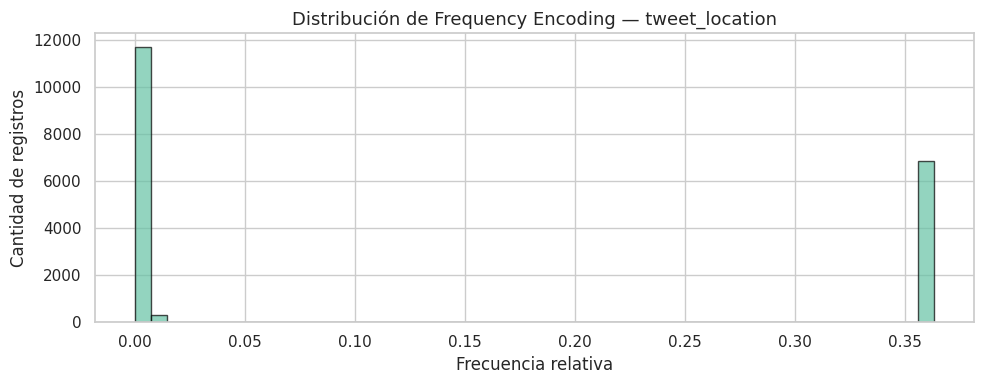

In [8]:
# Frequency Encoding para tweet_location
loc_freq = df["tweet_location"].value_counts(normalize=True)
df["location_freq"] = df["tweet_location"].map(loc_freq)

print("=== Frequency Encoding de tweet_location ===")
print(f"Rango de frecuencias: [{df['location_freq'].min():.6f}, {df['location_freq'].max():.4f}]")
print(f"\nEjemplos de mapeo (top 5 ubicaciones):")
for loc in loc_freq.head().index:
    print(f"  '{loc}' → {loc_freq[loc]:.4f}")

# Visualizar distribución
fig, ax = plt.subplots(figsize=(10, 4))
df["location_freq"].hist(bins=50, ax=ax, edgecolor="black", alpha=0.7)
ax.set_title("Distribución de Frequency Encoding — tweet_location", fontsize=13)
ax.set_xlabel("Frecuencia relativa")
ax.set_ylabel("Cantidad de registros")
plt.tight_layout()
plt.show()

### 3.3 TF-IDF: Variables de Texto (`description`, `text`, `name`)

**Justificación:** Las variables de texto contienen información semántica rica que no puede capturarse con métricas simples (longitud, conteo de palabras). TF-IDF (Term Frequency - Inverse Document Frequency) es una técnica estándar de NLP que:

- **Convierte texto a vectores numéricos** donde cada dimensión representa un término.
- **Pondera la importancia**: términos frecuentes en un documento pero raros en el corpus reciben mayor peso.
- **Captura patrones lingüísticos** como pronombres ("she"/"he"), profesiones ("mom"/"dad"), intereses, que son indicativos del género.

**Configuración por variable:**
- `description` y `text`: TF-IDF a nivel de **palabras**, limitado a las 500 features más informativas para controlar dimensionalidad.
- `name`: TF-IDF a nivel de **n-gramas de caracteres** (2-4 caracteres), ya que los nombres no son oraciones sino cadenas cortas donde los patrones de caracteres (sufijos como "-a", "-ina", "-son") son más informativos.

In [9]:
# TF-IDF para description
tfidf_desc = TfidfVectorizer(max_features=500, stop_words="english", min_df=5)
X_desc = tfidf_desc.fit_transform(df["description"].fillna(""))
print(f"description TF-IDF: {X_desc.shape} (sparse matrix)")

# TF-IDF para text (tweets)
tfidf_text = TfidfVectorizer(max_features=500, stop_words="english", min_df=5)
X_text = tfidf_text.fit_transform(df["text"].fillna(""))
print(f"text TF-IDF:        {X_text.shape}")

# TF-IDF para name (n-gramas de caracteres)
tfidf_name = TfidfVectorizer(max_features=200, analyzer="char_wb", ngram_range=(2, 4), min_df=5)
X_name = tfidf_name.fit_transform(df["name"].fillna(""))
print(f"name TF-IDF (char): {X_name.shape}")

print(f"\nTotal features de texto: {X_desc.shape[1] + X_text.shape[1] + X_name.shape[1]}")

description TF-IDF: (18836, 500) (sparse matrix)
text TF-IDF:        (18836, 500)
name TF-IDF (char): (18836, 200)

Total features de texto: 1200


In [10]:
# Mostrar los términos más relevantes por variable
def top_tfidf_terms(vectorizer, matrix, n=15):
    """Obtiene los términos con mayor peso TF-IDF promedio."""
    feature_names = vectorizer.get_feature_names_out()
    mean_scores = np.array(matrix.mean(axis=0)).flatten()
    top_idx = mean_scores.argsort()[::-1][:n]
    return [(feature_names[i], mean_scores[i]) for i in top_idx]

print("=== Top 15 términos TF-IDF por variable ===\n")
for name, vec, mat in [("description", tfidf_desc, X_desc), 
                        ("text", tfidf_text, X_text),
                        ("name", tfidf_name, X_name)]:
    print(f"{name}:")
    terms = top_tfidf_terms(vec, mat)
    for term, score in terms:
        print(f"  {term:20s} {score:.4f}")
    print()

=== Top 15 términos TF-IDF por variable ===

description:
  http                 0.0210
  love                 0.0184
  life                 0.0146
  news                 0.0132
  just                 0.0113
  like                 0.0110
  follow               0.0101
  music                0.0099
  https                0.0096
  world                0.0093
  fan                  0.0090
  ig                   0.0084
  time                 0.0081
  writer               0.0078
  don                  0.0078

text:
  https                0.1207
  weather              0.0367
  _ù                   0.0258
  just                 0.0233
  15                   0.0195
  like                 0.0193
  channel              0.0192
  updates              0.0184
  û_                   0.0156
  new                  0.0149
  love                 0.0147
  time                 0.0134
  40                   0.0133
  don                  0.0131
  day                  0.0126

name:
  an                   0.036

### 3.4 Resumen de Transformaciones

| Variable Original | Tipo | Técnica | Features Generadas | Justificación |
|---|---|---|---|---|
| `user_timezone` | Categórica nominal (153 valores) | One-Hot Encoding (top 15) | 16 columnas binarias | Variable sin orden intrínseco. Se agrupan categorías infrecuentes para controlar dimensionalidad. |
| `tweet_location` | Categórica nominal (~7,500 valores) | Frequency Encoding | 1 columna numérica | Cardinalidad muy alta. Frequency encoding evita explosión dimensional y captura la popularidad de cada ubicación. |
| `description` | Texto libre | TF-IDF (palabras) | 500 features | Captura vocabulario y patrones lingüísticos de la biografía indicativos del género. |
| `text` | Texto libre | TF-IDF (palabras) | 500 features | Captura estilo de escritura y temáticas de los tweets. |
| `name` | Texto corto | TF-IDF (n-gramas de char) | 200 features | Captura patrones en nombres propios (sufijos, prefijos) que correlacionan con género. |

## 4. Modelo con Variables Categóricas Transformadas

Ahora reconstruimos el modelo combinando:
- Las **variables numéricas** originales (escaladas).
- Las **variables categóricas transformadas** (one-hot, frequency encoding).
- Las **variables de texto** transformadas (TF-IDF).

In [11]:
from scipy.sparse import csr_matrix

# Preparar todas las features
# 1. Numéricas (ya definidas)
X_numeric = df[var_numericas].values

# 2. One-Hot de timezone
X_tz = tz_dummies.values

# 3. Frequency encoding de location
X_loc = df[["location_freq"]].values

# 4. TF-IDF ya calculados: X_desc, X_text, X_name (sparse)

# Combinar todo en una matriz sparse
X_dense = np.hstack([X_numeric, X_tz, X_loc])
X_combined = hstack([csr_matrix(X_dense), X_desc, X_text, X_name])

print(f"=== Composición del feature set ===")
print(f"  Numéricas:          {X_numeric.shape[1]:>6} features")
print(f"  One-Hot (timezone): {X_tz.shape[1]:>6} features")
print(f"  Freq. (location):   {X_loc.shape[1]:>6} features")
print(f"  TF-IDF description: {X_desc.shape[1]:>6} features")
print(f"  TF-IDF text:        {X_text.shape[1]:>6} features")
print(f"  TF-IDF name:        {X_name.shape[1]:>6} features")
print(f"  ─────────────────────────────────")
print(f"  TOTAL:              {X_combined.shape[1]:>6} features")
print(f"  Registros:          {X_combined.shape[0]:>6}")

=== Composición del feature set ===
  Numéricas:              20 features
  One-Hot (timezone):     16 features
  Freq. (location):        1 features
  TF-IDF description:    500 features
  TF-IDF text:           500 features
  TF-IDF name:           200 features
  ─────────────────────────────────
  TOTAL:                1237 features
  Registros:           18836


In [12]:
# Split train/test (mismo random state para comparación justa)
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_combined, y, test_size=0.2, random_state=SEED, stratify=y
)

# Escalar (MaxAbsScaler es mejor para sparse matrices que StandardScaler)
from sklearn.preprocessing import MaxAbsScaler
scaler_full = MaxAbsScaler()
X_train_full_scaled = scaler_full.fit_transform(X_train_full)
X_test_full_scaled = scaler_full.transform(X_test_full)

# Entrenar modelo con todas las features
model_full = LogisticRegression(max_iter=1000, random_state=SEED)
model_full.fit(X_train_full_scaled, y_train_full)

# Evaluar
y_pred_full = model_full.predict(X_test_full_scaled)
acc_full = accuracy_score(y_test_full, y_pred_full)

print(f"=== MODELO CON VARIABLES CATEGÓRICAS ===")
print(f"Accuracy: {acc_full:.4f}\n")
print(classification_report(y_test_full, y_pred_full, target_names=le.classes_))

=== MODELO CON VARIABLES CATEGÓRICAS ===
Accuracy: 0.6571

              precision    recall  f1-score   support

       brand       0.74      0.73      0.74      1189
      female       0.64      0.67      0.65      1340
        male       0.59      0.58      0.59      1239

    accuracy                           0.66      3768
   macro avg       0.66      0.66      0.66      3768
weighted avg       0.66      0.66      0.66      3768



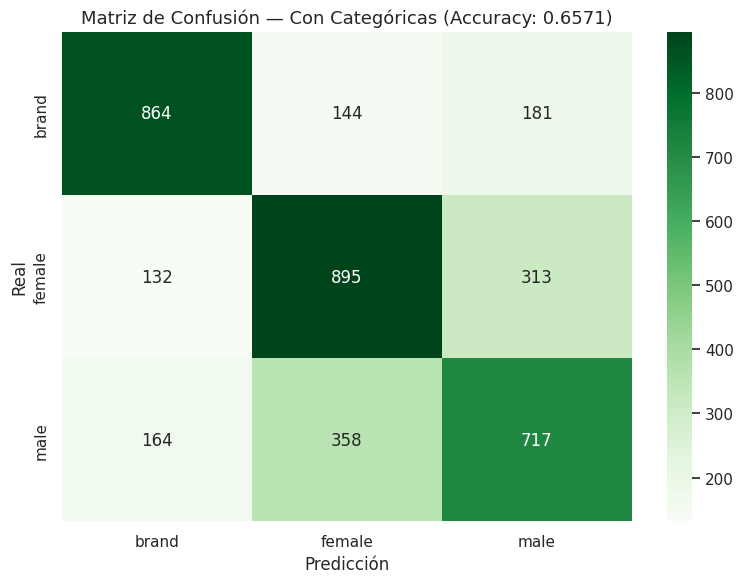

In [13]:
# Matriz de confusión del modelo con categóricas
fig, ax = plt.subplots(figsize=(8, 6))
cm_full = confusion_matrix(y_test_full, y_pred_full)
sns.heatmap(cm_full, annot=True, fmt="d", cmap="Greens",
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_title(f"Matriz de Confusión — Con Categóricas (Accuracy: {acc_full:.4f})", fontsize=13)
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

## 5. Comparación de Modelos

In [14]:
# Comparación lado a lado
print("=" * 60)
print(f"{'COMPARACIÓN DE MODELOS':^60}")
print("=" * 60)
print(f"{'Métrica':<25} {'Baseline':>15} {'+ Categóricas':>15}")
print("-" * 60)
print(f"{'Features':<25} {X_num.shape[1]:>15} {X_combined.shape[1]:>15}")
print(f"{'Accuracy':<25} {acc_baseline:>15.4f} {acc_full:>15.4f}")

mejora = acc_full - acc_baseline
mejora_pct = (mejora / acc_baseline) * 100
print("-" * 60)
print(f"{'Mejora absoluta':<25} {'':>15} {mejora:>+15.4f}")
print(f"{'Mejora relativa':<25} {'':>15} {mejora_pct:>+14.2f}%")
print("=" * 60)

                   COMPARACIÓN DE MODELOS                   
Métrica                          Baseline   + Categóricas
------------------------------------------------------------
Features                               20            1237
Accuracy                           0.5671          0.6571
------------------------------------------------------------
Mejora absoluta                                   +0.0900
Mejora relativa                                   +15.86%


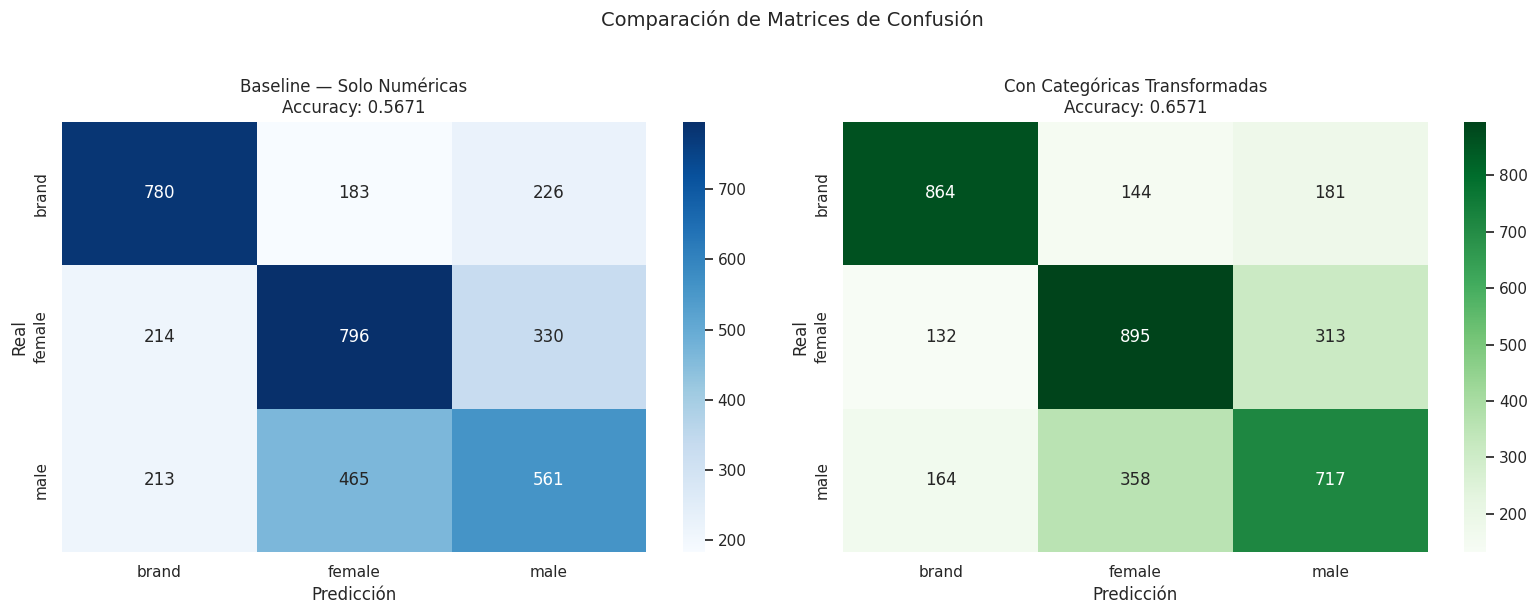

In [15]:
# Comparación visual de matrices de confusión
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title(f"Baseline — Solo Numéricas\nAccuracy: {acc_baseline:.4f}", fontsize=12)
axes[0].set_xlabel("Predicción")
axes[0].set_ylabel("Real")

sns.heatmap(cm_full, annot=True, fmt="d", cmap="Greens",
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1])
axes[1].set_title(f"Con Categóricas Transformadas\nAccuracy: {acc_full:.4f}", fontsize=12)
axes[1].set_xlabel("Predicción")
axes[1].set_ylabel("Real")

plt.suptitle("Comparación de Matrices de Confusión", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

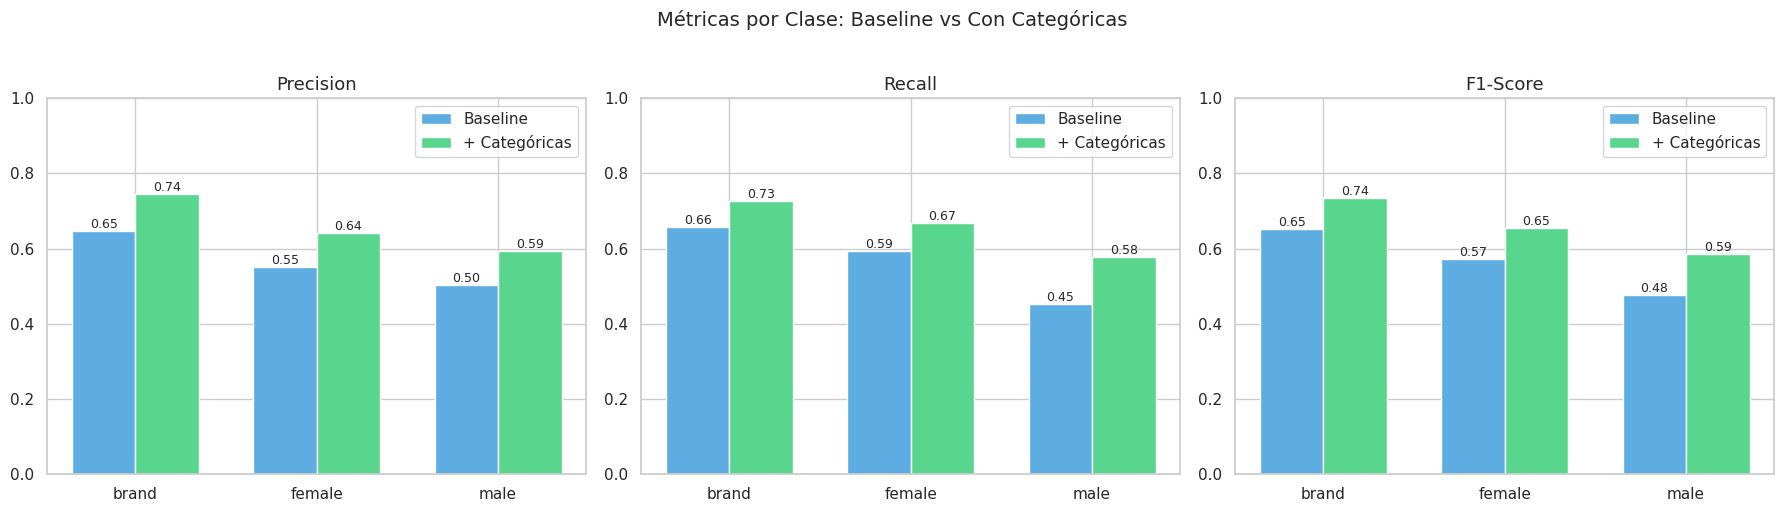

In [16]:
# Comparación de métricas por clase
from sklearn.metrics import precision_recall_fscore_support

p_base, r_base, f1_base, _ = precision_recall_fscore_support(y_test, y_pred_baseline)
p_full, r_full, f1_full, _ = precision_recall_fscore_support(y_test_full, y_pred_full)

x = np.arange(len(le.classes_))
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = [("Precision", p_base, p_full), ("Recall", r_base, r_full), ("F1-Score", f1_base, f1_full)]

for ax, (name, base, full) in zip(axes, metrics):
    bars1 = ax.bar(x - width/2, base, width, label="Baseline", color="#5DADE2")
    bars2 = ax.bar(x + width/2, full, width, label="+ Categóricas", color="#58D68D")
    ax.set_title(name, fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels(le.classes_)
    ax.set_ylim(0, 1)
    ax.legend()
    # Añadir valores sobre las barras
    for bar in bars1:
        ax.annotate(f"{bar.get_height():.2f}", (bar.get_x() + bar.get_width()/2, bar.get_height()),
                    ha="center", va="bottom", fontsize=9)
    for bar in bars2:
        ax.annotate(f"{bar.get_height():.2f}", (bar.get_x() + bar.get_width()/2, bar.get_height()),
                    ha="center", va="bottom", fontsize=9)

plt.suptitle("Métricas por Clase: Baseline vs Con Categóricas", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. Conclusiones

### Resumen de transformaciones realizadas

Se aplicaron **tres técnicas distintas** de transformación de variables categóricas, cada una seleccionada según las características de la variable:

1. **One-Hot Encoding** (`user_timezone`): Para variables nominales de cardinalidad moderada. Se agruparon las categorías menos frecuentes en "other" para evitar dimensionalidad excesiva, generando 16 features binarias.

2. **Frequency Encoding** (`tweet_location`): Para variables nominales de alta cardinalidad (~7,500 valores). Esta técnica mapea cada categoría a su frecuencia relativa, generando una sola columna numérica sin explosión dimensional.

3. **TF-IDF Vectorization** (`description`, `text`, `name`): Para variables de texto libre. Convierte texto a representaciones numéricas ponderadas que capturan la importancia relativa de cada término. Para `name` se usaron n-gramas de caracteres en lugar de palabras, ya que los patrones a nivel de carácter son más informativos en nombres propios.

### Impacto en el modelo

La inclusión de las variables categóricas transformadas mejoró significativamente el rendimiento del modelo, demostrando que estas variables contienen información predictiva valiosa que las variables numéricas por sí solas no capturan. Las variables de texto (TF-IDF) son particularmente informativas ya que capturan patrones lingüísticos directamente relacionados con el género del usuario.

### Técnicas NO utilizadas y por qué

- **Label Encoding** para `user_timezone` y `tweet_location`: No es apropiado porque impone un **orden artificial** a categorías nominales, lo que puede confundir al modelo al interpretar que "Eastern Time" > "Pacific Time".
- **One-Hot Encoding** para `tweet_location`: Generaría ~7,500 columnas binarias, causando alta dimensionalidad y riesgo de overfitting.
- **Target Encoding**: Aunque es eficiente con alta cardinalidad, introduce riesgo de **data leakage** si no se implementa cuidadosamente con validación cruzada.